[init] futures=803 | levers=45 | exog=14
[saved] Electric Power Sector PNG: E:\Current_2023\WI\work\ssp_louisiana\metamodel\data\outputs\figs_png\parallel_axes_Energy.png
[saved] Electric Power Sector PDF: E:\Current_2023\WI\work\ssp_louisiana\metamodel\data\outputs\figs_pdf\parallel_axes_Energy.pdf


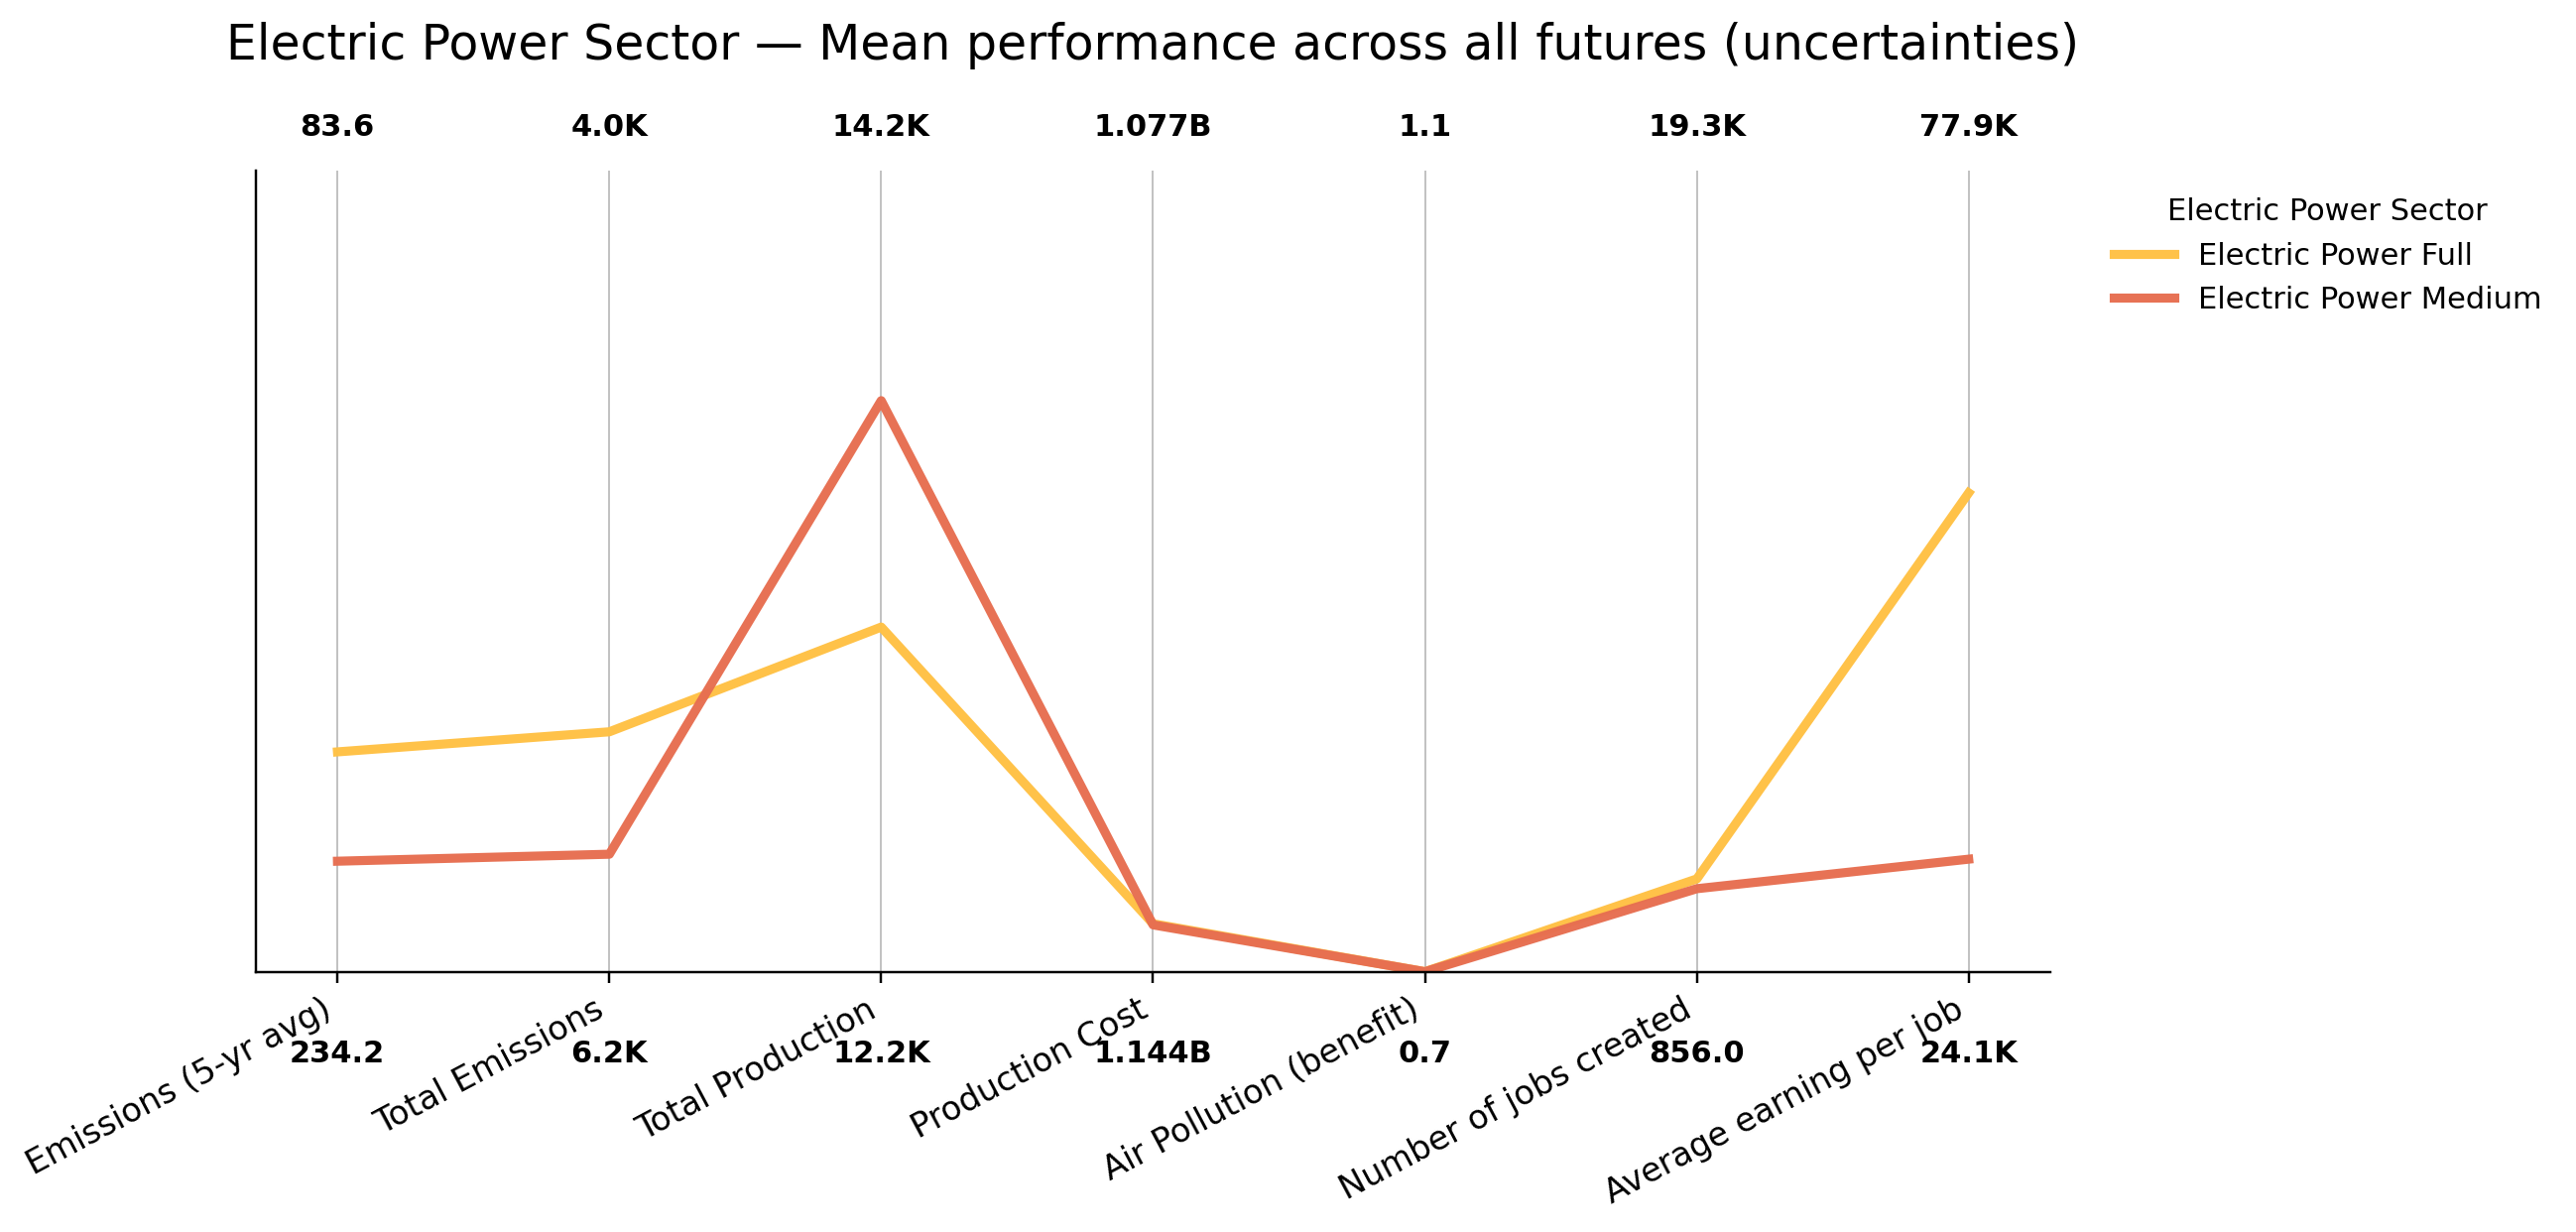

[saved] Industrial Sector PNG: E:\Current_2023\WI\work\ssp_louisiana\metamodel\data\outputs\figs_png\parallel_axes_Industry.png
[saved] Industrial Sector PDF: E:\Current_2023\WI\work\ssp_louisiana\metamodel\data\outputs\figs_pdf\parallel_axes_Industry.pdf


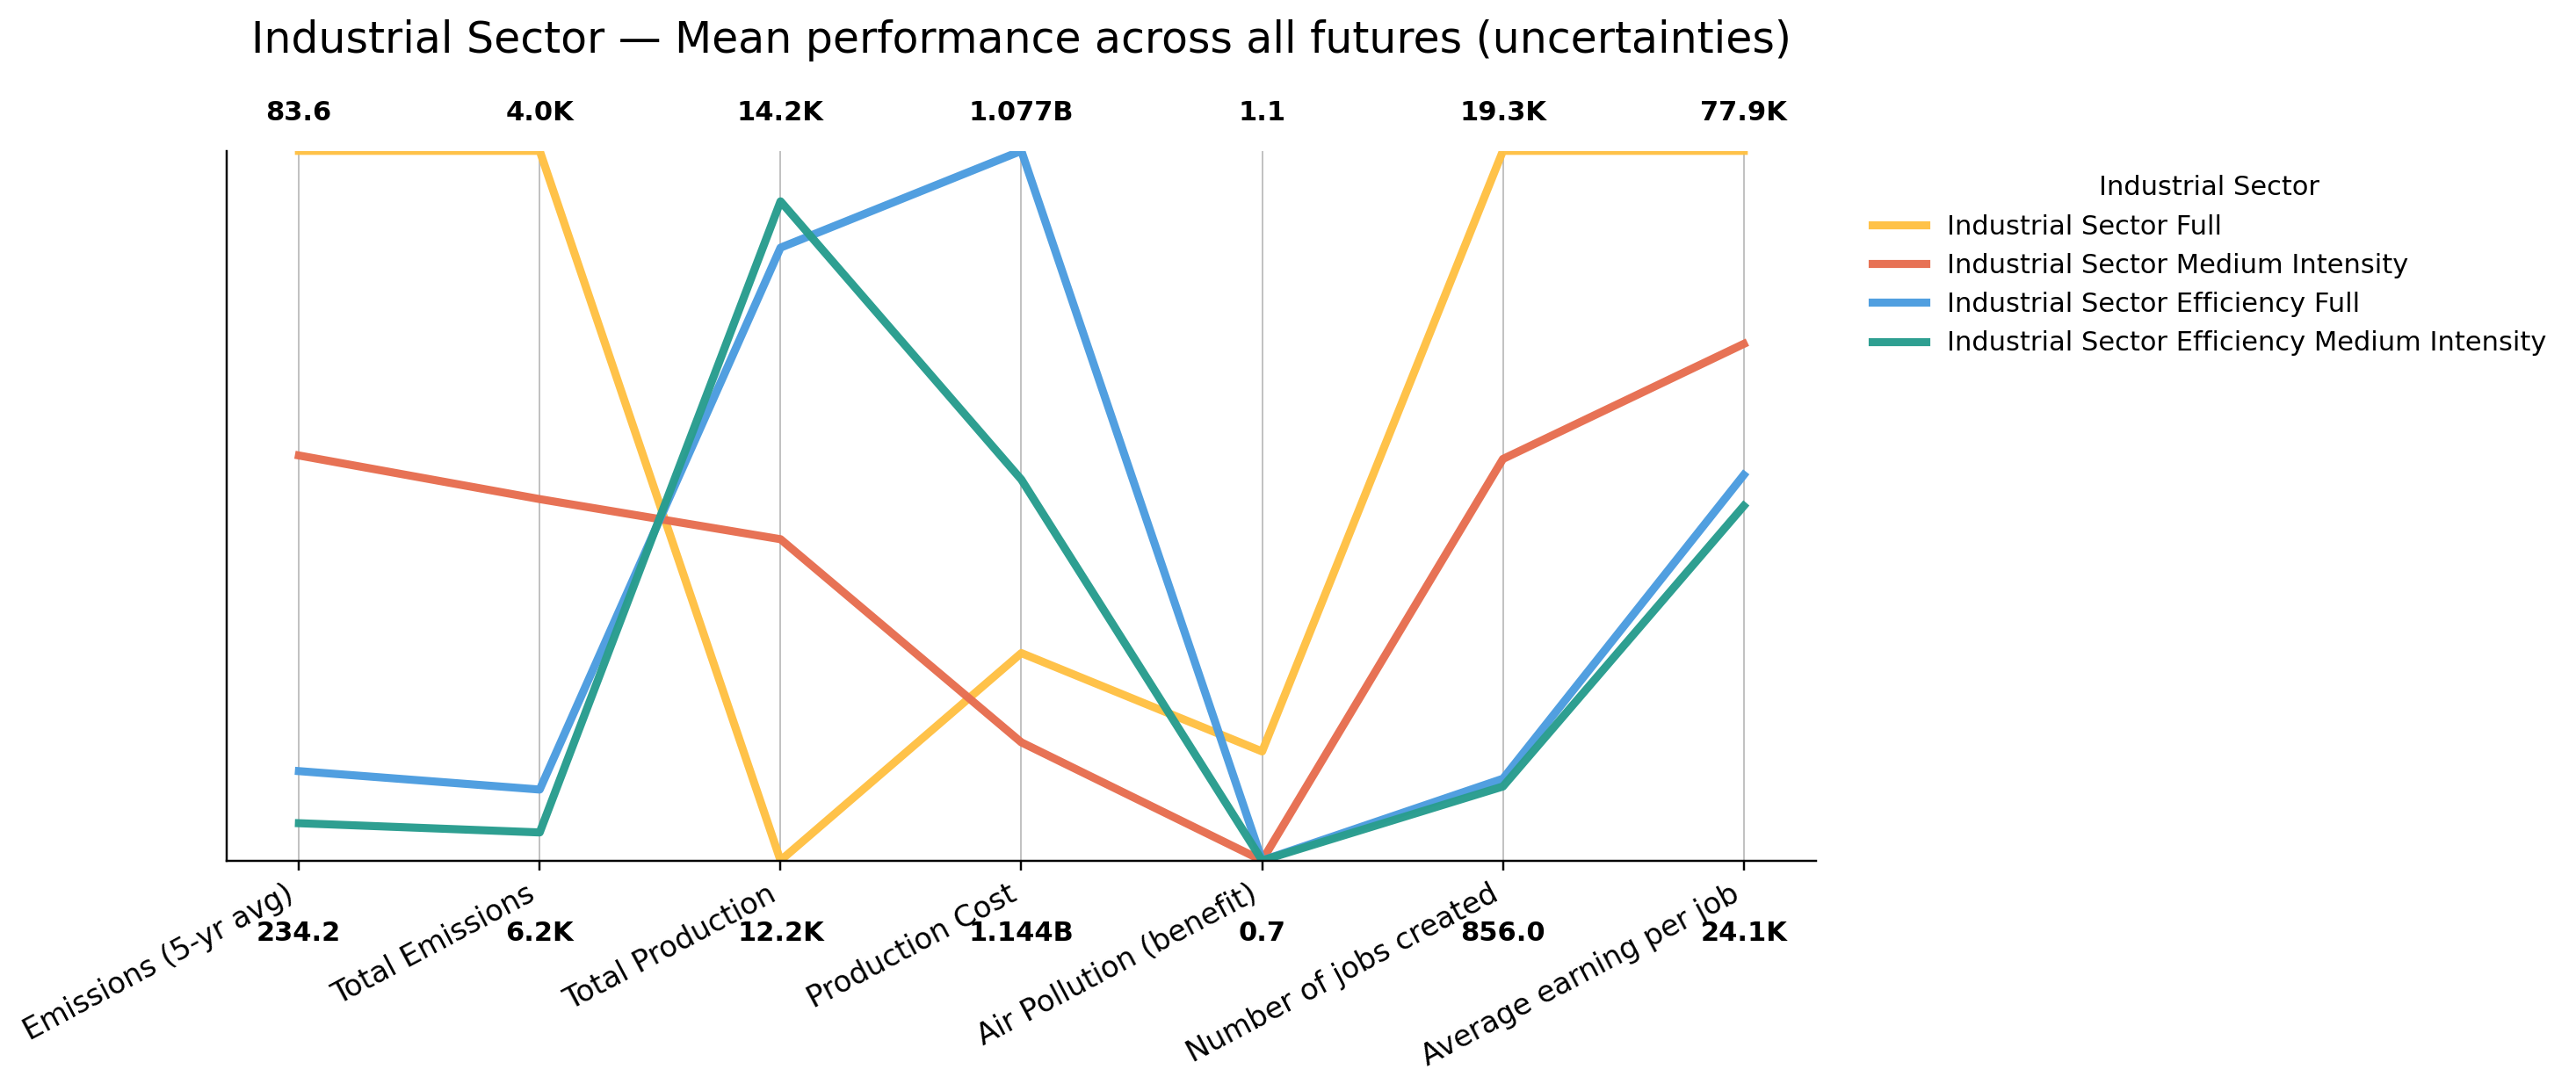

[saved] Buildings + Transportation Sector PNG: E:\Current_2023\WI\work\ssp_louisiana\metamodel\data\outputs\figs_png\parallel_axes_Buildings_Transportation.png
[saved] Buildings + Transportation Sector PDF: E:\Current_2023\WI\work\ssp_louisiana\metamodel\data\outputs\figs_pdf\parallel_axes_Buildings_Transportation.pdf


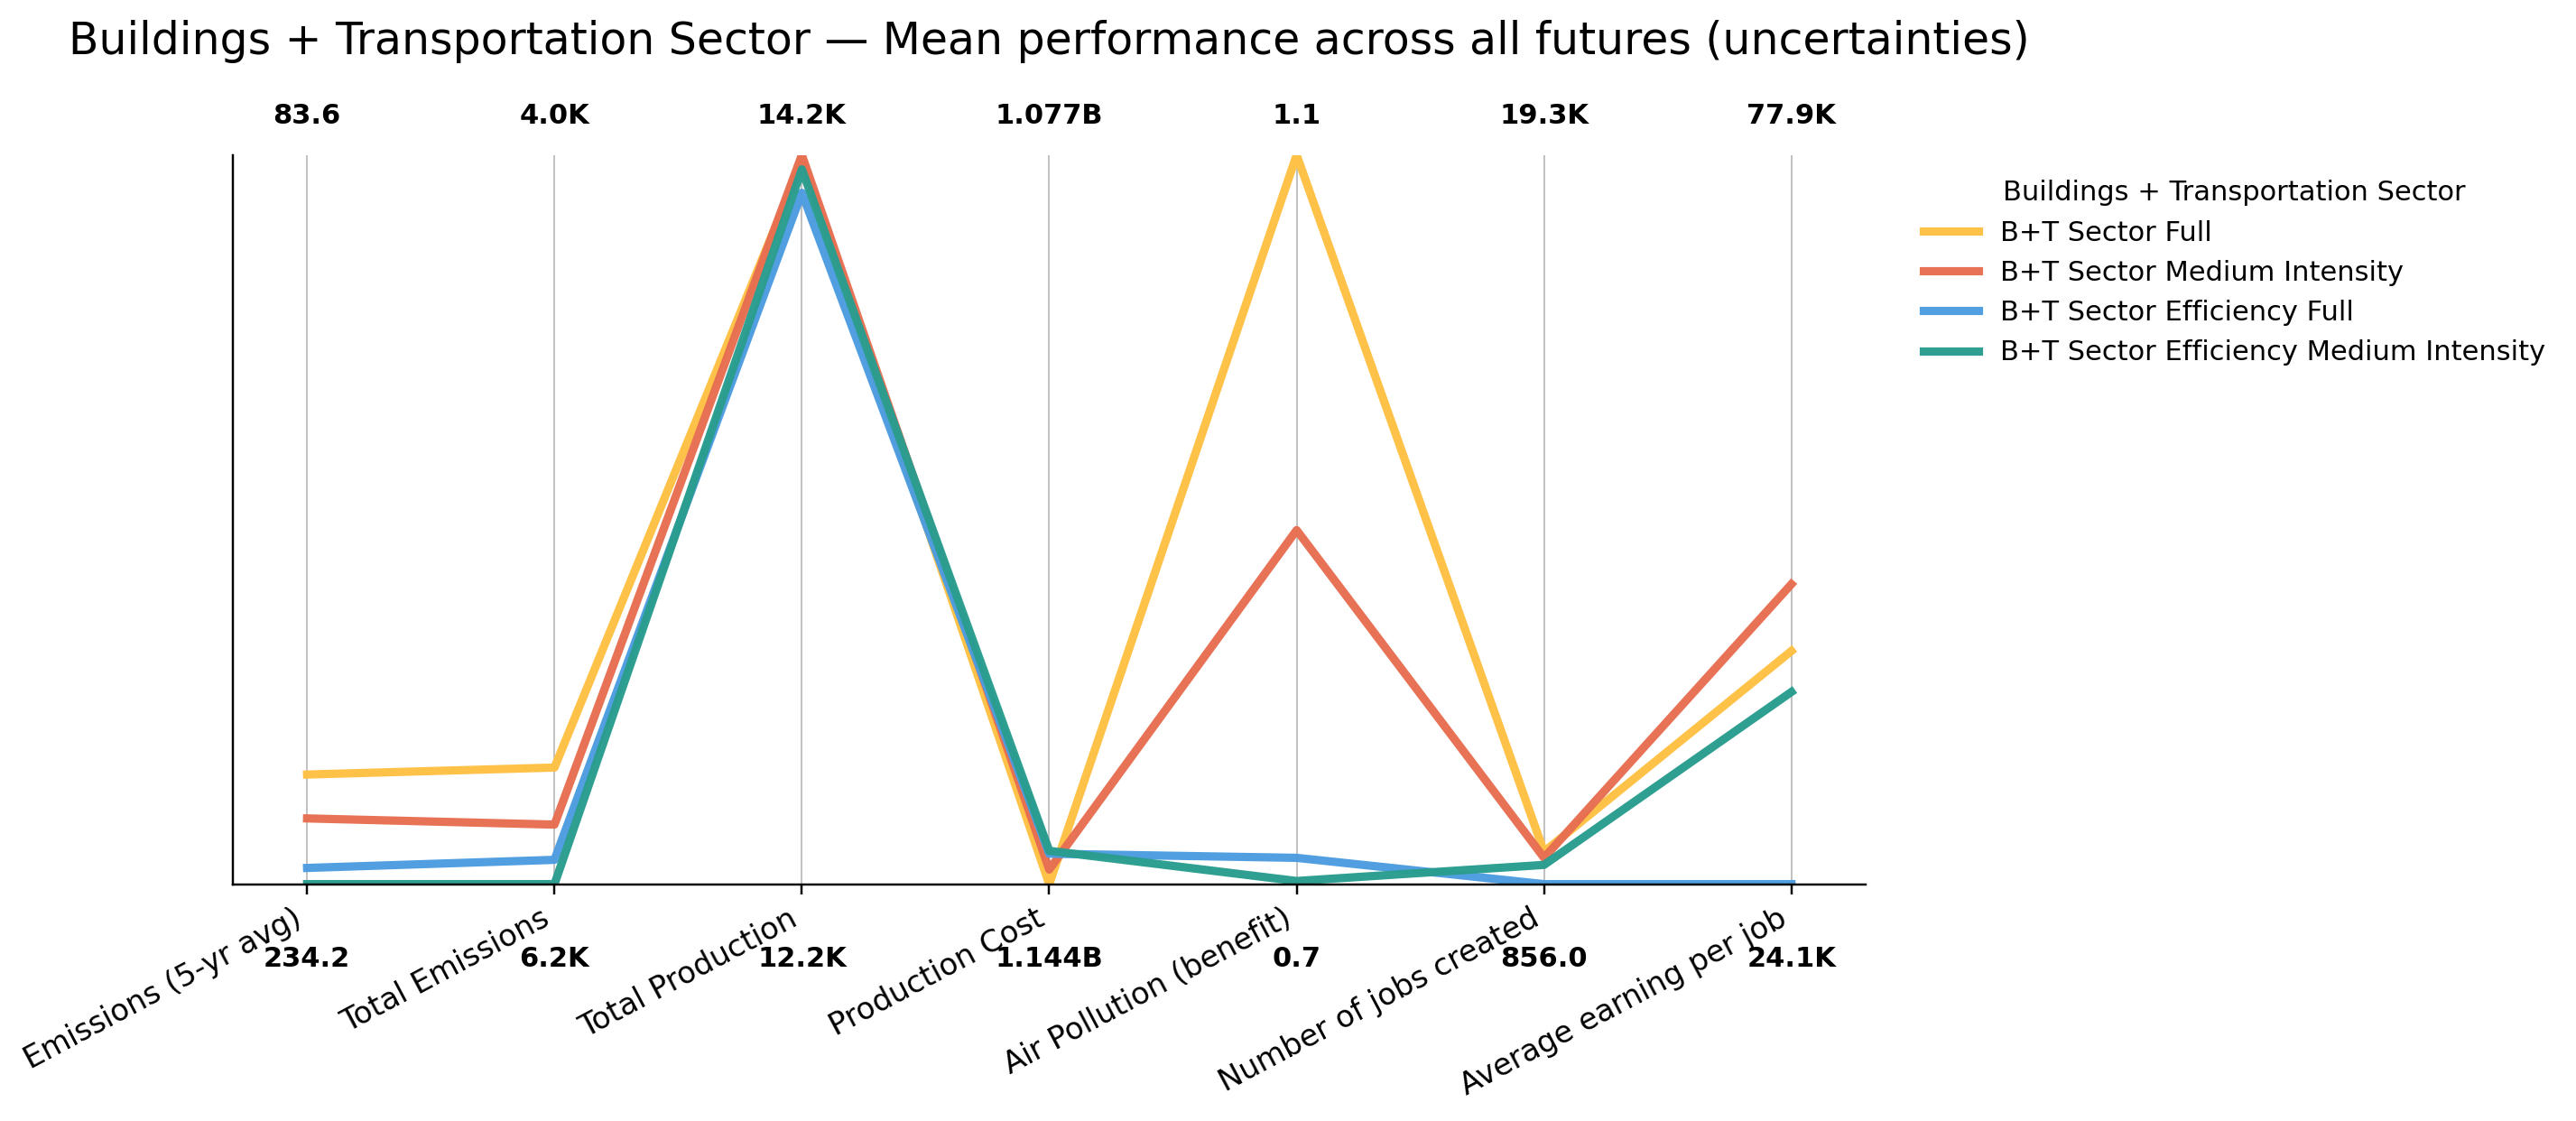

[DONE] All three sector plots saved with consistent normalization across sectors.


In [2]:
# === Fixed Sector Policies Across Uncertainties — Parallel Axes (no optimization) ===
"""
Purpose
-------
Create multiple *fixed* lever policies for three sectors (Energy, Industry,
Building + Transportation). For each policy:
  • All levers default to 0
  • Selected lever *groups* are set to specified values (1.0 or 0.5)
Evaluate each policy across all *exogenous futures* (group_<N> with N >= 46),
aggregate by MEAN across futures, and render three parallel-axes plots (one per
sector). Axes are normalized with a SINGLE global scaler fit over the union of
all sector-policy results → consistent scale across the three plots.

Assumptions
-----------
- Features follow 'group_<N>...' naming.
  * Levers:    N < 46
  * Exogenous: N >= 46
- Non-group_* features (if any) are filled with the column-wise median of X_ref.
- Model 'pipeline' supports .predict(X) and outputs columns in 'train_metrics' order.

Outputs
-------
- PNG/PDF figures under outputs/figs_png and outputs/figs_pdf:
    * parallel_axes_Energy.png/.pdf
    * parallel_axes_Industry.png/.pdf
    * parallel_axes_Buildings_Transportation.png/.pdf
"""

import os, re
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Tuple, Iterable
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# ---- File paths (edit if needed) ----
SCRIPT_DIR_PATH = os.getcwd()
TRAINED_MODELS_DIR = Path(SCRIPT_DIR_PATH) / "trained_models"
MODEL_PATH = TRAINED_MODELS_DIR / "xgb_pipeline_5.9.pkl"
TRAIN_DF_PATH = TRAINED_MODELS_DIR / "xgb_pipeline_5.9_training_df.parquet"

# Output directory for PDFs/PNGs
PDF_ABS_DIR = Path(r"E:\Current_2023\WI\work\ssp_louisiana\metamodel\data\outputs")
PDF_ABS_DIR.mkdir(parents=True, exist_ok=True)
FIGS_PNG_DIR = PDF_ABS_DIR / "figs_png"
FIGS_PDF_DIR = PDF_ABS_DIR / "figs_pdf"
FIGS_PNG_DIR.mkdir(parents=True, exist_ok=True)
FIGS_PDF_DIR.mkdir(parents=True, exist_ok=True)

# ---- Load model & data ----
import joblib
pipeline = joblib.load(MODEL_PATH)
full_df = pd.read_parquet(TRAIN_DF_PATH)

# ---- Features and reference X ----
feature_cols = list(pipeline.feature_names_in_)
X_ref = full_df[feature_cols].copy()

# ---- Metrics (must match model's predict() output column order) ----
train_metrics = [
    "emission_avg_last_five_years",
    "emission_total",
    "production_total",
    "production_cost_total",
    "technical_cost",
    "air_pollution",
    "num_jobs",
    "earning_per_job",
]

# ---- Display labels and senses (flip 'min' so up=better on plot) -------------
label_map = {
    "emission_total": "Total Emissions",
    "emission_avg_last_five_years": "Emissions (5-yr avg)",
    "production_total": "Total Production",
    "production_cost_total": "Production Cost",
    "technical_cost": "Technical Cost",
    "air_pollution": "Air Pollution (benefit)",
    "num_jobs": "Number of jobs created",
    "earning_per_job": "Average earning per job",
}
sense_by_obj = {
    "emission_avg_last_five_years": "min",
    "emission_total": "min",
    "production_total": "max",
    "production_cost_total": "min",
    "technical_cost": "min",
    "air_pollution": "max",
    "num_jobs": "max",
    "earning_per_job": "max",
}
# Metrics to show (exclude technical_cost to match your prior figs)
metrics_plot = [
    "emission_avg_last_five_years",
    "emission_total",
    "production_total",
    "production_cost_total",
    "air_pollution",
    "num_jobs",
    "earning_per_job",
]

# ----  palette for line colors -----------------------------------
base_palette = [
    "#FFC145", "#E76F51", "#4D9DE0",
    "#2A9D8F", "#264653", "#8AB17D",
    "#F4A261", "#A06CD5", "#6E9887", "#EFCA08"
]

# ---- Identify levers (<46) and exogenous (>=46) columns ----------------------
_rx_num = re.compile(r"^group_(\d+)(?:_|$)")
def _group_num(col: str) -> int | None:
    m = _rx_num.match(col)
    return int(m.group(1)) if m else None

lever_cols = [c for c in feature_cols if (_group_num(c) is not None and _group_num(c) < 46)]
exog_cols  = [c for c in feature_cols if (_group_num(c) is not None and _group_num(c) >= 46)]
if not exog_cols:
    raise ValueError("No exogenous columns detected: expected 'group_<N>' with N >= 46.")

# Build exogenous futures from unique combos in data
scenario_rows = X_ref.drop_duplicates(subset=exog_cols, keep="first").reset_index(drop=True)
SCENARIOS: List[dict] = [{c: float(row[c]) for c in exog_cols} for _, row in scenario_rows.iterrows()]

print(f"[init] futures={len(SCENARIOS)} | levers={len(lever_cols)} | exog={len(exog_cols)}")

# ---- Helpers -----------------------------------------------------------------
def _ensure_numeric_schema(df_like: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    df = df_like.copy()
    df = df.reindex(columns=cols)
    # fill non-group_* with median if missing
    non_group = [c for c in cols if _group_num(c) is None]
    if non_group:
        med = X_ref[non_group].median(numeric_only=True)
        for c in non_group:
            if c in df.columns and df[c].isna().any():
                df[c] = df[c].fillna(med.get(c, 0.0))
    df = df.astype("float32")
    if df.isna().any().any():
        raise ValueError("NaNs present in features after schema alignment.")
    return df

def _predict_metrics_for_rows_across_futures(pipeline, df_rows: pd.DataFrame,
                                             scenarios: List[dict], metrics: list[str]) -> np.ndarray:
    """
    Returns array with shape (N_rows, N_scenarios, N_metrics) of raw predictions.
    For each scenario, exogenous columns are overwritten with that scenario's values.
    """
    if df_rows is None or len(df_rows) == 0:
        return np.zeros((0, max(1, len(scenarios)), max(1, len(metrics))), dtype=float)
    N = len(df_rows); S = len(scenarios); M = len(metrics)
    out = np.zeros((N, S, M), dtype=float)
    for s_idx, scen in enumerate(scenarios):
        Xs = df_rows.copy()
        for k, v in scen.items():
            if k in Xs.columns:
                Xs[k] = float(v)
        Y = pipeline.predict(Xs)
        Y = pd.DataFrame(Y, columns=train_metrics)[metrics].to_numpy(dtype=float)
        out[:, s_idx, :] = Y
    return out

def _metric_table_mean(df_rows: pd.DataFrame, *, scenarios, metrics) -> pd.DataFrame:
    """Predict metrics for df_rows across scenarios and aggregate by MEAN across futures."""
    A = _predict_metrics_for_rows_across_futures(pipeline, df_rows, scenarios, metrics)
    R = A.mean(axis=1)
    return pd.DataFrame(R, columns=metrics, index=df_rows.index)

def _kmb(v: float, *, decimals: int = 1) -> str:
    """
    Format with K/M/B suffixes and configurable decimals.
    """
    a = abs(v)
    if a >= 1_000_000_000:
        return f"{v/1_000_000_000:.{decimals}f}B"
    if a >= 1_000_000:
        return f"{v/1_000_000:.{decimals}f}M"
    if a >= 1_000:
        return f"{v/1_000:.{decimals}f}K"
    return f"{v:.{decimals}f}"


def _annotate_axis_extrema(ax, stack_df: pd.DataFrame, metrics: list[str], senses: dict[str,str]):
    """
    Show raw min/max for each metric at top/bottom to retain scale intuition.
    Uses 3 decimals ONLY for 'production_cost_total', otherwise 1.
    """
    for i, c in enumerate(metrics):
        vmin, vmax = float(stack_df[c].min()), float(stack_df[c].max())
        is_min = senses.get(c, "max").lower().startswith("min")
        top_val = vmin if is_min else vmax
        bot_val = vmax if is_min else vmin

        # 3 dp just for production_cost_total; 1 dp for all others
        dp = 3 if c == "production_cost_total" else 1

        ax.text(i, 1.035, _kmb(top_val, decimals=dp), ha="center", va="bottom",
                fontsize=10, fontweight="bold")
        ax.text(i, -0.085, _kmb(bot_val, decimals=dp), ha="center", va="top",
                fontsize=10, fontweight="bold")


def _normalize_parts_global(parts_raw: list[pd.DataFrame], metrics: list[str], senses: dict[str,str]):
    """
    Fit one scaler on the vertical stack of ALL raw parts (across sectors/policies),
    then transform each. Flip 'min' metrics so higher=better.
    """
    stack_df = pd.concat(parts_raw, axis=0)
    scaler = MinMaxScaler().fit(stack_df[metrics].to_numpy(dtype=float))
    parts_norm = []
    for df_in in parts_raw:
        vals = scaler.transform(df_in[metrics].to_numpy(dtype=float))
        df = pd.DataFrame(vals, columns=metrics, index=df_in.index)
        for c in metrics:
            if senses.get(c, "max").lower().startswith("min"):
                df[c] = 1.0 - df[c]
        parts_norm.append(df)
    return parts_norm, stack_df

# ---- Utilities to build policies by GROUP number sets -------------------------
def _dedup_sorted(nums: Iterable[int]) -> list[int]:
    return sorted(set(int(n) for n in nums))

def make_policy_from_groups(base_row: pd.DataFrame, lever_cols: list[str],
                            groups_to_values: Dict[int, float]) -> pd.DataFrame:
    """
    All levers → 0, then for each group G in groups_to_values, set every column
    whose name starts with 'group_{G}' to that value.
    """
    out = base_row.copy()
    # Zero all levers
    for c in lever_cols:
        out[c] = 0.0
    # Set groups
    for g, val in groups_to_values.items():
        prefix = f"group_{int(g)}"
        for c in lever_cols:
            if c.startswith(prefix):
                out[c] = float(val)
    return _ensure_numeric_schema(out, feature_cols)

# Base row: column-wise median to keep non-group_* reasonable
base_row = _ensure_numeric_schema(X_ref.median(numeric_only=True).to_frame().T, feature_cols)

# =========================
# Sector 1 — ENERGY (group_6*)
# =========================
# Energy policies (from your earlier request)
energy_policies_cfg = {
    "Electric Power Full":   {6: 1.0},  # all group_6* levers = 1.0
    "Electric Power Medium": {6: 0.5},  # all group_6* levers = 0.5
}

# =========================
# Sector 2 — INDUSTRY
# =========================
# Lists as you specified (deduplicated)
_industry_full_groups = _dedup_sorted([4,5,6,7,8,9,10,11,12,13,14,15,25])
_industry_eff_groups  = _dedup_sorted([9,10])

industry_policies_cfg = {
    "Industrial Sector Full":                {g: 1.0 for g in _industry_full_groups},
    "Industrial Sector Medium Intensity":    {g: 0.5 for g in _industry_full_groups},
    "Industrial Sector Efficiency Full":     {g: 1.0 for g in _industry_eff_groups},
    "Industrial Sector Efficiency Medium Intensity": {g: 0.5 for g in _industry_eff_groups},
}

# =========================
# Sector 3 — BUILDINGS + TRANSPORTATION
# =========================
# Provided lists (deduped). NOTE: Your text repeated 38 and 40; duplicates removed.
_bt_full_groups     = _dedup_sorted([26,27,28,32,33,34,35,36,37,38,40,41])
_bt_medium_groups   = _dedup_sorted([26,27,28,32,33,34,35,36,37,38,40,41])  # assumed 26 (not 6)
_bt_eff_groups      = _dedup_sorted([26,27,32,33])

bt_policies_cfg = {
    "B+T Sector Full":                {g: 1.0 for g in _bt_full_groups},
    "B+T Sector Medium Intensity":    {g: 0.5 for g in _bt_medium_groups},
    "B+T Sector Efficiency Full":     {g: 1.0 for g in _bt_eff_groups},
    "B+T Sector Efficiency Medium Intensity": {g: 0.5 for g in _bt_eff_groups},
}

# ---- Build all policy rows and evaluate across futures ------------------------
def build_policy_tables(policies_cfg: Dict[str, Dict[int, float]]) -> Dict[str, pd.DataFrame]:
    """Returns dict policy_name -> raw-metric row (mean across futures)."""
    out: Dict[str, pd.DataFrame] = {}
    for name, groups_map in policies_cfg.items():
        row = make_policy_from_groups(base_row, lever_cols, groups_to_values=groups_map)
        tbl = _metric_table_mean(row, scenarios=SCENARIOS, metrics=metrics_plot)  # mean across futures
        tbl.index = pd.Index([name], name="policy")
        out[name] = tbl
    return out

energy_raw   = build_policy_tables(energy_policies_cfg)
industry_raw = build_policy_tables(industry_policies_cfg)
bt_raw       = build_policy_tables(bt_policies_cfg)

# ---- Build global normalization stack (ALL sectors/policies together) ---------
all_parts_raw = list(energy_raw.values()) + list(industry_raw.values()) + list(bt_raw.values())
all_norm_parts, global_stack_df = _normalize_parts_global(all_parts_raw, metrics_plot, sense_by_obj)

# Unpack back to sector-scoped normalized dicts (preserve original order)
cursor = 0
def _slice_norm(norm_parts, count): 
    global cursor
    chunk = norm_parts[cursor: cursor + count]
    cursor += count
    return chunk

energy_norm_parts   = _slice_norm(all_norm_parts, len(energy_raw))
industry_norm_parts = _slice_norm(all_norm_parts, len(industry_raw))
bt_norm_parts       = _slice_norm(all_norm_parts, len(bt_raw))

def _rebind(names: list[str], parts: list[pd.DataFrame]) -> Dict[str, pd.DataFrame]:
    return {n: p for n, p in zip(names, parts)}

energy_norm   = _rebind(list(energy_raw.keys()), energy_norm_parts)
industry_norm = _rebind(list(industry_raw.keys()), industry_norm_parts)
bt_norm       = _rebind(list(bt_raw.keys()), bt_norm_parts)

# ---- Plotting (one figure per sector) -----------------------------------------
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.titlesize": 16, "axes.labelsize": 13, "xtick.labelsize": 11, "ytick.labelsize": 11,
})

def plot_sector_parallel_axes(
    sector_name: str,
    policy_tables_norm: Dict[str, pd.DataFrame],
    *, stack_for_annotations: pd.DataFrame,
    metrics: list[str], senses: dict[str,str],
    labels_map: dict[str,str],
    colors: list[str],
    save_png_dir: Path, save_pdf_dir: Path,
    filename_stem: str
):
    fig, ax = plt.subplots(figsize=(11.5, 6.8), dpi=220)
    x = np.arange(len(metrics))
    xlabels = [labels_map.get(c, c) for c in metrics]

    # vertical axes
    for i in range(len(metrics)):
        ax.vlines(i, 0, 1, color="#BDBDBD", linewidth=0.6, zorder=0)

    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=28, ha="right")
    ax.set_yticks([])

    # annotate raw min/max using the global stack (consistent across all three figs)
    _annotate_axis_extrema(ax, stack_for_annotations, metrics, senses)

    # draw each policy line
    handles = []
    names = list(policy_tables_norm.keys())
    for i, name in enumerate(names):
        df = policy_tables_norm[name]
        line = ax.plot(x, df.iloc[0][metrics], lw=3.0, alpha=0.98,
                       label=name, color=colors[i % len(colors)])[0]
        handles.append(line)

    ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False, title=sector_name)
    ax.set_title(f"{sector_name} — Mean performance across all futures (uncertainties)", pad=26, y=1.04)
    fig.subplots_adjust(top=0.78, bottom=0.24, right=0.84)

    png_path = save_png_dir / f"{filename_stem}.png"
    pdf_path = save_pdf_dir / f"{filename_stem}.pdf"
    plt.savefig(png_path, bbox_inches="tight", dpi=420)
    plt.savefig(pdf_path, bbox_inches="tight", format="pdf")
    print(f"[saved] {sector_name} PNG: {png_path}")
    print(f"[saved] {sector_name} PDF: {pdf_path}")
    plt.show()
    plt.close(fig)

# ---- Render the three figures -------------------------------------------------
plot_sector_parallel_axes(
    "Electric Power Sector",
    energy_norm,
    stack_for_annotations=global_stack_df,
    metrics=metrics_plot, senses=sense_by_obj, labels_map=label_map,
    colors=base_palette,
    save_png_dir=FIGS_PNG_DIR, save_pdf_dir=FIGS_PDF_DIR,
    filename_stem="parallel_axes_Energy"
)

plot_sector_parallel_axes(
    "Industrial Sector",
    industry_norm,
    stack_for_annotations=global_stack_df,
    metrics=metrics_plot, senses=sense_by_obj, labels_map=label_map,
    colors=base_palette,
    save_png_dir=FIGS_PNG_DIR, save_pdf_dir=FIGS_PDF_DIR,
    filename_stem="parallel_axes_Industry"
)

plot_sector_parallel_axes(
    "Buildings + Transportation Sector",
    bt_norm,
    stack_for_annotations=global_stack_df,
    metrics=metrics_plot, senses=sense_by_obj, labels_map=label_map,
    colors=base_palette,
    save_png_dir=FIGS_PNG_DIR, save_pdf_dir=FIGS_PDF_DIR,
    filename_stem="parallel_axes_Buildings_Transportation"
)

print("[DONE] All three sector plots saved with consistent normalization across sectors.")
